**Descrption of this Notebook:**
This notebook analyses reported urban issues from the ZüriWieNeu platform in the city of Zurich. In the previous notebooks, the raw report data were cleaned, converted into spatial point data, and joined with Zurich neighbourhood polygons. As a result, each report is now connected to a specific neighbourhood.

The goal of this notebook is to use the prepared spatial dataset to explore patterns in reported urban issues across Zurich. The analysis focuses on both spatial and temporal patterns, such as which neighbourhoods receive the most reports, which problem categories are most common, and whether certain types of issues are concentrated in specific areas.

The dataset used in this notebook is the processed GeoPackage created after the spatial join : reports_with_quartiere. It contains the cleaned report attributes, point geometries, and neighbourhood information such as neighbourhood name, neighbourhood number, district name, and district number.

By the end of this notebook, at least four research questions will be answered using code, summary tables, plots, and maps. These results help to better understand how reported urban problems are distributed across Zurich and how they vary by category, neighbourhood, and time.

Expected output:
- a table and visualization (bar chart) of which neighborhood and Kreis receives the highest amount of reports
- a table and little insight of which category of report is most common
- a visualization (bar chart) of the progress of reports per month and per year
- a table of concentraing cateogry in the neighborhoods
- a visualisation (map) of the dominat category in each neighborhood
- a visalisation (map) of the precentage of the dominat category in each neighborhood
- a table /statistics on the progressing time of each category
- a visualisation (boxplot) of the progressing time of each category
- a visualisation (map) of the report datapoints and the neighborhoods (polygons)

In [1]:
#all important libaries for this notebook are loaded first
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

Firstly, the processed Geopackage is loaded as geo data frame. This dataset already contains both the report information and the neighbourhood information from the spatial join.

In [2]:
#import my processed geodata frame
reports_with_quartiere = gpd.read_file(
    "../data/processeddata/reports_with_quartiere.gpkg",
    layer="reports_with_quartiere"
)

Secondly, the loaded geodata frame is inspected, to make sure, every important variable is available and the data frame is complete. For that, i use some basic definitions, like .head(), .info(), .crs.

In [3]:
reports_with_quartiere.head(2)

,service_request_id,requested_datetime,updated_datetime,e,n,service_code,status,title,detail,service_notice,year_requested,month_requested,weekday_requested,processing_time_days,index_right,quartier_name,quartier_number,kreis_name,kreis_number,geometry
0,1,2013-03-14 15:16:15,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,Diese Reparatur wird von uns in den kommenden ...,2013,3,Thursday,28.696701,16,Albisrieden,91,Kreis 9,9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,fixed - council,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,Diese Reparatur wird von uns in den kommenden ...,2013,3,Thursday,28.696123,20,Höngg,101,Kreis 10,10,POINT (2680746 1249916)


In [4]:
reports_with_quartiere.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72606 entries, 0 to 72605
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   service_request_id    72606 non-null  int64   
 1   requested_datetime    72606 non-null  str     
 2   updated_datetime      72606 non-null  str     
 3   e                     72606 non-null  int64   
 4   n                     72606 non-null  int64   
 5   service_code          72606 non-null  str     
 6   status                72606 non-null  str     
 7   title                 72604 non-null  str     
 8   detail                72604 non-null  str     
 9   service_notice        71750 non-null  str     
 10  year_requested        72606 non-null  int64   
 11  month_requested       72606 non-null  int64   
 12  weekday_requested     72606 non-null  str     
 13  processing_time_days  72606 non-null  float64 
 14  index_right           72606 non-null  int64   

In [5]:
reports_with_quartiere.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

The loaded geodataframe looks complete and correct. Only the datetime(requested and updated) are representet as string type again. If i want to analyise or visualise something with the whole datetime column, it has to be represneted as date type and not string. That's why i will convert it in the follwoing code cell.

In [6]:
# by makking a list, i can write a loop, instead of converting both datetime alone.
date_cols_gdf = [
    "requested_datetime",
    "updated_datetime"
]
#the for loop iterates trhough the list and converts the whole list
for col in date_cols_gdf:
    reports_with_quartiere[col] = pd.to_datetime(
        reports_with_quartiere[col],
        format="%Y-%m-%d %H:%M:%S",
    )
#instead of analysing all the types and information i only look at the date_cols, so it's not using much space in my analyse but still chekcs the conversion
reports_with_quartiere[date_cols_gdf].dtypes

requested_datetime    datetime64[us]
updated_datetime      datetime64[us]
dtype: object

Now, both the datetime have the right type for further analyises.

This analysis is guided by the follwoing research Questions:
- *Which neighborood in Zurich receives the highest amount of reports?*
- *Which categories are the most common across the city of Zurich?*
- *How does the number of reports vary per month? vary per year?*
- *Are certain problem categories concentrated in specific neighbourhoods?*
- *Does processing time differ by different categories?*

**Question 1:** Which neighorhoods in Zurich receives the highest amount of reports?

To analise this question, the reports per Quartiere (quartier_name) were counted and sorted, so the Quartier with most reports is on top. Afterwards the Information is visualized in a bar chart.  Also interested in how the pattern changes from analysing it in a larger scale,the same codes werde performed for the Kreise (kreis_name).

In [7]:
reports_per_quartier = (
    reports_with_quartiere
    .groupby("quartier_name")
    # the dataset was grouped by the quartiere, with the name it is more clear and more specified
    .size()
    #this functions counts how many times the quartiername is in the reports
    .sort_values(ascending=False)
    #this function sorts the values and with ascending = False, it sorts it from top to bottom
)

reports_per_quartier.head(10)
#i am only interested in the top 10, and not all 36 Quartiere, that would be to much to visualize

quartier_name
Langstrasse    6185
Sihlfeld       5233
Altstetten     4092
Unterstrass    3594
Wipkingen      3304
Höngg          3090
Oerlikon       2984
Hard           2854
Wollishofen    2834
Enge           2756
dtype: int64

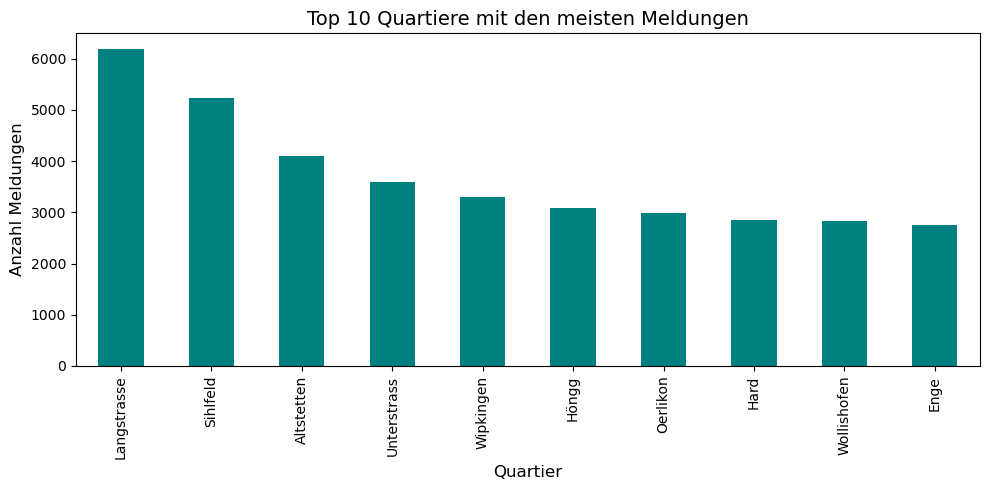

In [8]:
ax = reports_per_quartier.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    color="teal"
)

ax.set_title("Top 10 Quartiere mit den meisten Meldungen", fontsize=14)
ax.set_xlabel("Quartier", fontsize=12)
ax.set_ylabel("Anzahl Meldungen", fontsize=12)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

In [9]:
reports_per_kreise = (
    reports_with_quartiere
    # the dataset was grouped by the kreise, with the name it is more clear and more specified
    .groupby("kreis_name")
    #this functions counts how many times the kreis_name is in the reports
    .size()
     #this function sorts the values and with ascending = False, it sorts it from top to bottom
    .sort_values(ascending=False)
)

reports_per_kreise.head(5)
#only top 5, because there are just 12 kreise, so it doesnt have to be 10.

kreis_name
Kreis 4     10568
Kreis 3      9150
Kreis 11     8023
Kreis 10     6394
Kreis 2      6222
dtype: int64

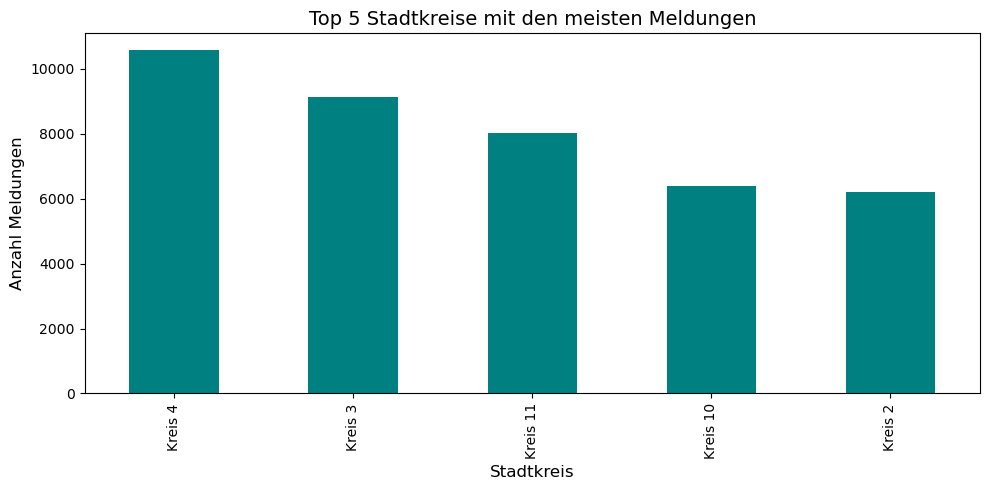

In [10]:
ax = reports_per_kreise.head(5).plot(
    kind="bar",
    figsize=(10, 5),
    color="teal"
)

ax.set_title("Top 5 Stadtkreise mit den meisten Meldungen", fontsize=14)
ax.set_xlabel("Stadtkreis", fontsize=12)
ax.set_ylabel("Anzahl Meldungen", fontsize=12)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

**Interpretation:**
We see that the Quartier Langstrasse has the most reports. Shilfeld and Altstetten are following up, but still 1000 reports less than the Langstrasse Quartier. Growing up in Zurich, this makes sense, because Langstrasse is famous for long nights of partying, alcohol and vandalism, which can maybye lead to more damages of public infrastructure. It also did not surprise me, that Quartiere in Kreis 7 and 8, the richer areas of Zruich have less damages to report than the top 10 ranked. An intereseting pattern on larger scale is also, that Kreis 9 is not in the top 5 Ranking of most Reports, eventhough the Quartier Altstetten (Kreis 9) is the third ranked Quartier counting Reports. That means that Albisrieden, the other Quartier in Kreis 9 doesn't have much reports. 

Whats important to note is that these counts are a absolut number. It is not relative, like the absolute rports devided by the the area or people living in that area. We can't calculate that, because we don't have this kind of data in the dataset.

**Question 2:** Which categories are the most common across the city of Zurich?

To answer this Question, the Categories of the Repots were counted. The Variable service_code was used, because it's the most simple categorization and not so details, therefore a fixed cateorgy.They were counted and sorted.
The analysis uses absolute counts, which show the total number of reports per category. 

In [11]:
category_counts = (
    reports_with_quartiere
    # the dataset was grouped by the service_codes so only the short cateogry is counted
    .groupby("service_code")
    #this functions counts how many times the service_codes is in the reports
    .size()
     #this function sorts the values and with ascending = False, it sorts it from top to bottom
    .sort_values(ascending=False)
)

category_counts

service_code
Abfall/Sammelstelle          27339
Signalisation/Lichtsignal    10972
Strasse/Trottoir/Platz        9868
Grünflächen/Spielplätze       7234
Beleuchtung/Uhren             5407
Allgemein                     3964
Graffiti                      3759
VBZ/ÖV                        1881
Brunnen/Hydranten             1287
Schädlinge                     895
dtype: int64

In [12]:
#filtered for the column service code, where it is the most reported one for details, to get some insight on what this category could mean
reports_with_quartiere.loc[
    reports_with_quartiere["service_code"] == "Abfall/Sammelstelle",
    ["service_code", "detail"]
].head(20)

,service_code,detail
4,Abfall/Sammelstelle,Arbeitskiste ist rund herum verschmiert
32,Abfall/Sammelstelle,Schmierereien und Graffiti an der Wand und am ...
43,Abfall/Sammelstelle,Dieses defekte Velo versperrt seit Monaten den...
56,Abfall/Sammelstelle,Defektes Velo seit Monaten dort.
68,Abfall/Sammelstelle,Bitte Abfallsäcke aufräumen. Die Bewohner konn...
70,Abfall/Sammelstelle,Ilegalle deponie Überlandstrasse 215 beim Brunnen
71,Abfall/Sammelstelle,Illegale Entsorgung
109,Abfall/Sammelstelle,Grill am Straßenrand entsorgt.
111,Abfall/Sammelstelle,"Graffiti bei Treppe zum Grossmünster, neben Ha..."
126,Abfall/Sammelstelle,Die Unterführung Bucheggstrasse ist schmutzig ...


**Interpretation:**
The Category Abfall/sammelstelle is almost three times more reported than the second most reported Category. But looking at the details about the 20 first Cateogry Abfall/Sammelstelle, cou can also see how it often corrleates with dirty streets or walls. Some of these reports are maybye missleading in the Category Abfall/Sammelstelle. The same could be with the other categories. But still with this many reports, it's maybye the most important category.

**Question 3:** How does the number of reports vary per month? vary per year?

This question examines temporal patterns in the ZüriWieNeu reports. The goal is to understand whether the number of reports changes over time and whether there are seasonal patterns. For this purpose, the reports are grouped by year and by month. Analysing reports by year shows long-term changes in reporting activity. Analysing reports by month helps identify possible seasonal patterns. 

Both were directly visualised to see the macro level pattern and not look at numbers, because especially in months with visualization the effect is better visible.

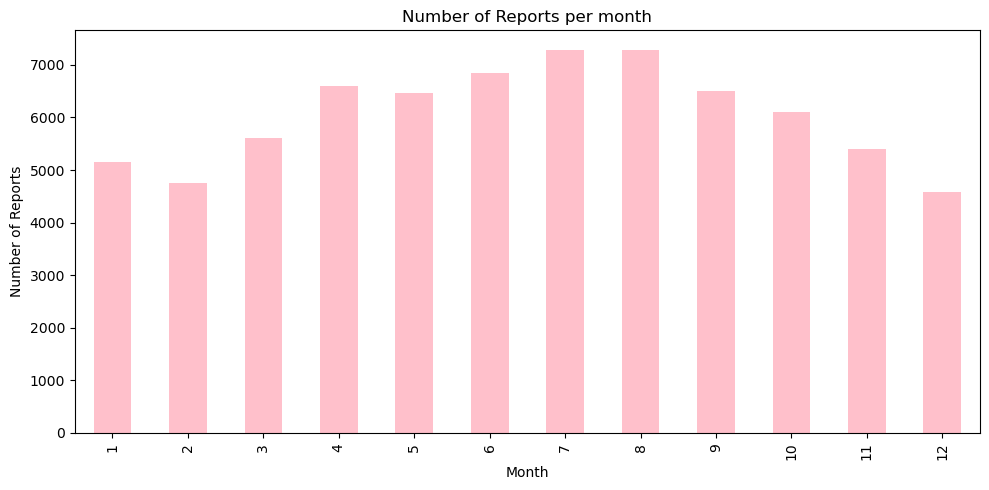

In [13]:
reports_per_month = (
    reports_with_quartiere
    # the dataset was grouped by the month_requested 
    .groupby("month_requested")
    #this functions counts how many times the month_requested is in the reports
    .size()
)

ax = reports_per_month.plot(
    x="month_requested",
    y="number_of_reports",
    kind="bar",
    figsize=(10, 5),
    color= "pink",
    legend=False
)

ax.set_title("Number of Reports per month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reports")
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

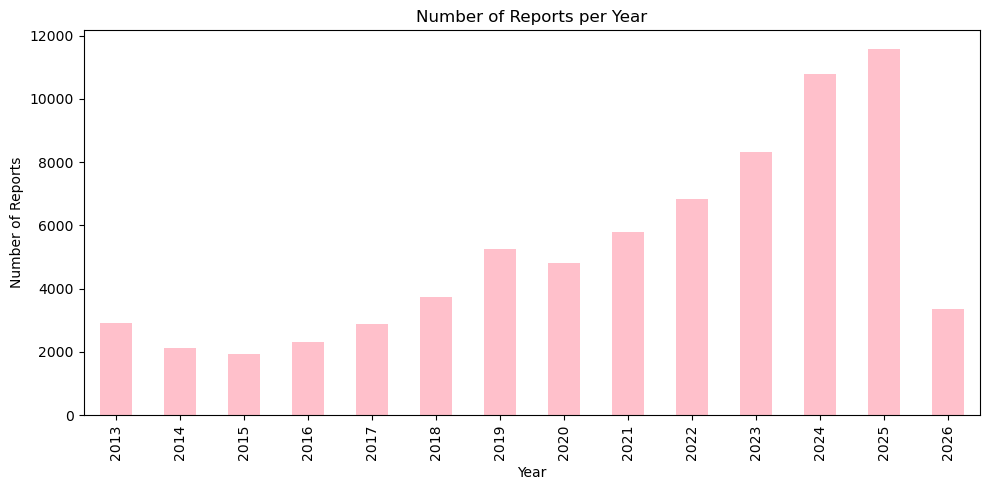

In [14]:
reports_per_year = (
    reports_with_quartiere
    # the dataset was grouped by the month_requested 
    .groupby("year_requested")
    #this functions counts how many times the month_requested is in the reports
    .size()
)
ax = reports_per_year.plot(
    x="year_requested",
    y="number_of_reports",
    kind="bar",
    figsize=(10, 5),
    color= "pink",
    legend=False
)
ax.set_title("Number of Reports per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Reports")

# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

**Interpretation:**
Looking at the number of reports per month, there can be a little peak identified in the summer months (6-8). Then the number of reports is declining again. Also Apirl has a high amount of reports. My interpretation of this pattern is, that people are more outside in the summer months than in the winter. This leads to more complicatiosn at "Abfall" or also "Graffiti" or " maybe Grünflächen und Spielplätze", but also to more reports, because people who report stuff like this are more outside aswell.

Looking at the number of reports per year, it is a clear trend to more reports with more years. Except the 2026, but this can be ignored, because whiloe downloading the reports dataset, it was only april, so only 4 months of 12. Otherwise there is a little less reports during 2020, which could be because of the corona Pandemic. The rising sum of reports over the year could be a sign of more people in Zurich reporting these things or also due to techonoloogical progress.

**Question 4:** Are certain problem categories concentrated in specific neighbourhoods?

This question investigates whether specific types of reports occur more frequently in some neighbourhoods than in others. To answer this, the number of reports is counted for each combination of neighbourhood and report category.
Both absolute counts and relative shares are useful. Absolute counts show where a category occurs most often, while relative shares show whether a category is especially important within a neighbourhood compared to other categories.

In [15]:
category_by_quartier = pd.crosstab(
    reports_with_quartiere["quartier_name"],
    reports_with_quartiere["service_code"]
)

category_by_quartier.head()

service_code,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
quartier_name,,,,,,,,,,
Affoltern,779,109,246,30,133,308,40,374,327,73
Albisrieden,644,107,137,66,53,265,45,346,336,48
Alt-Wiedikon,1278,148,168,28,35,146,27,331,295,46
Altstetten,1400,254,242,131,177,331,79,776,592,110
City,437,139,109,31,96,95,4,374,381,74


In [16]:
dominant_category = (
    reports_with_quartiere
    .groupby(["quartier_name", "service_code"])
    .size()
    .reset_index(name="n_reports")
)

dominant_per_quartier = (
    dominant_category
    .sort_values(["quartier_name", "n_reports"], ascending=[True, False])
    .drop_duplicates(subset="quartier_name")
)

In [17]:
quartiere_dominant = zh_quartiere_clean.merge(
    dominant_per_quartier,
    on="quartier_name",
    how="left"
)

NameError: name 'zh_quartiere_clean' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

quartiere_dominant.plot(
    column="service_code",
    categorical=True,
    legend=True,
    figsize=(12, 12),
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Most Common Report Category by Neighbourhood")
ax.set_axis_off()

plt.show()

In [ ]:
quartier_totals = (
    reports_with_quartiere
    .groupby("quartier_name")
    .size()
    .reset_index(name="total_reports")
)
dominant_per_quartier = dominant_per_quartier.merge(
    quartier_totals,
    on="quartier_name",
    how="left"
)
dominant_per_quartier["dominant_share"] = (
    dominant_per_quartier["n_reports"] / dominant_per_quartier["total_reports"]
)
quartiere_dominant = zh_quartiere_clean.merge(
    dominant_per_quartier,
    on="quartier_name",
    how="left"
)
fig, ax = plt.subplots(figsize=(12, 12))

quartiere_dominant.plot(
    column="dominant_share",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Share of the Most Common Report Category by Neighbourhood")
ax.set_axis_off()

plt.show()

**Question 5:** Does processing time differ by different categories?

This question examines whether the time between a report being submitted and updated differs by report category. The analysis uses the "processing_time_days" column, which was calculated during the data cleaning step.
Because processing times can contain strong outliers, the median processing time is used as the main comparison measure. The mean and maximum values are also calculated, but they are interpreted more carefully because they can be strongly influenced by very long individual cases.

In [ ]:
processing_by_category = (
    processing_reports
    .groupby("service_code")["processing_time_days"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

processing_by_category = processing_by_category.sort_values(
    "median",
    ascending=False
)

processing_by_category

In [ ]:
boxplot_data = processing_reports.copy()

fig, ax = plt.subplots(figsize=(12, 6))

boxplot_data.boxplot(
    column="processing_time_days",
    by="service_code",
    ax=ax,
    rot=45
)

ax.set_title("Processing Time by Report Category")
ax.set_xlabel("Category")
ax.set_ylabel("Processing time in days")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
zh_quartiere_clean = gpd.read_file("../data/processeddata/zh_quartiere_clean.gpkg", layer="zh_quartiere_clean")

In [ ]:
import matplotlib.pyplot as plt

kreis_polygons = (
    zh_quartiere_clean
    .dissolve(by="kreis_number")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 12))

zh_quartiere_clean.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8
)

kreis_polygons.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

reports_with_quartiere.plot(
    ax=ax,
    column="service_code",
    categorical=True,
    legend=True,
    markersize=3,
    alpha=0.6
)

# Kreisnummern anzeigen
kreis_centroids = (
    zh_quartiere_clean
    .dissolve(by="kreis_number")
    .reset_index()
)

for idx, row in kreis_centroids.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        str(row["kreis_number"]),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center"
    )

ax.set_title("Top 10 Report Categories with District Numbers")
ax.set_axis_off()

plt.show()